# Load data and train/test split

Everyone uses this. Run these cells first.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt

df = pd.read_parquet("combined_preprocessed.parquet")
print(df.shape)


(6304794, 134)


In [2]:
# Drop leakage columns (only known AFTER the flight — kept in preprocessed for EDA only)
leak_cols = [
    "DEP_DELAY",
    "ARR_DELAY",
    "DEP_DEL15",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "DIVERTED",
    "DEST_AIRPORT_SEQ_ID",
]
X = df.drop(columns=[c for c in leak_cols + ["DELAY_CLASS"] if c in df.columns])
y = df["DELAY_CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class distribution — train:")
print(y_train.value_counts(normalize=True).sort_index())


Train: (5043835, 124), Test: (1260959, 124)
Class distribution — train:
DELAY_CLASS
0    0.780265
1    0.072238
2    0.066119
3    0.048023
4    0.033354
Name: proportion, dtype: float64


Helper function so everyone reports the same metrics.

In [3]:
CLASS_NAMES = ['No Delay', '15-29 min', '30-59 min', '1-2 hr', '2+ hr']

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'):.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cm, cmap='Blues')
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=10)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'),
    }

In [4]:
results = []

**most difficult task -- what features should we use??**

**what features we should drop?? one by one**

**and then, One-hot encoding so that we can add the destination in there**

---
# Wahid — Naive Bayes

In [5]:
from sklearn.naive_bayes import GaussianNB

# TODO (Wahid):
# 1. Create the model
# 2. Fit on X_train, y_train
# 3. results.append(evaluate('Naive Bayes', nb_model, X_test, y_test))


---
# Sam — Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# TODO (Sam):
# 1. Create model with: max_iter=1000, class_weight='balanced', random_state=42
# 2. Fit on X_train, y_train
# 3. results.append(evaluate('Logistic Regression', lr_model, X_test, y_test))

X_train_s = X_train.sample(n=500_000, random_state=42)
y_train_s = y_train.loc[X_train_s.index]
X_train_s = X_train_s.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

lr_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)), 
    ('clf', LogisticRegression(
        solver='saga',
        max_iter=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,  
    )),
])
lr_model.fit(X_train_s, y_train_s)

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=200,
                                    n_jobs=-1, random_state=42,
                                    solver='saga'))])

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


--- Logistic Regression ---
Accuracy:  0.0735
Precision: 0.7526
Recall:    0.0735
F1:        0.0164
AUC-ROC:   0.6420

              precision    recall  f1-score   support

    No Delay       0.95      0.00      0.00    983882
   15-29 min       0.07      0.88      0.13     91090
   30-59 min       0.00      0.00      0.00     83374
      1-2 hr       0.08      0.19      0.11     60555
       2+ hr       0.06      0.01      0.01     42058

    accuracy                           0.07   1260959
   macro avg       0.23      0.22      0.05   1260959
weighted avg       0.75      0.07      0.02   1260959



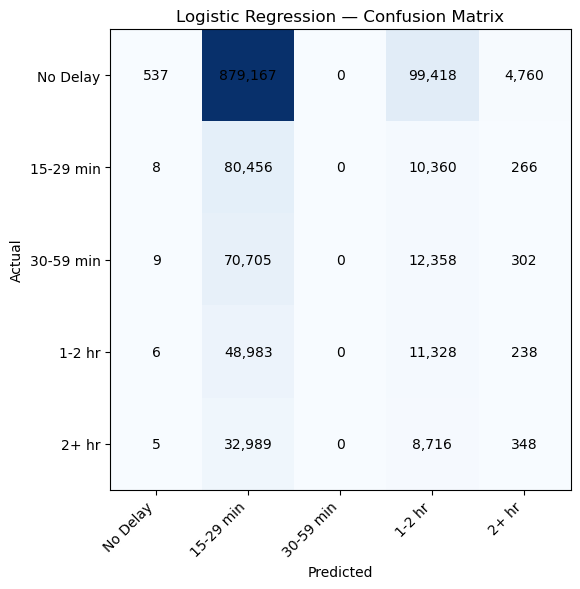

In [9]:
results.append(evaluate('Logistic Regression', lr_model, X_test, y_test))

Text(0.5, 1.0, 'Top 15 Features by |Coefficient| — Logistic Regression')

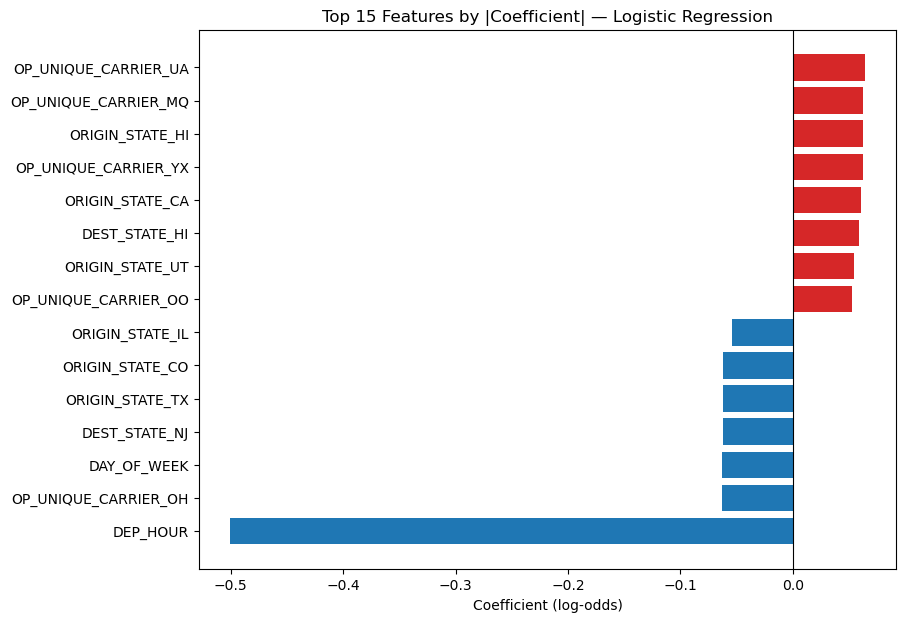

In [10]:
# TODO (Sam): Feature importance plot
# 1. Get coefficients from lr_model.coef_[0]
# 2. Find the top 15 by absolute value
# 3. Plot as horizontal bar chart
coefs = lr_model.named_steps['clf'].coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs),
})

top15 = coef_df.nlargest(15, 'abs_coef').sort_values('coef')

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in top15['coef']]
ax.barh(top15['feature'], top15['coef'], color=colors)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 15 Features by |Coefficient| — Logistic Regression')

---
# Wahid — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# TODO (Wahid):
# 1. Create model with: n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
# 2. Fit on X_train, y_train
# 3. results.append(evaluate('Random Forest', rf_model, X_test, y_test))


In [ ]:
# TODO (Wahid): Feature importance plot
# 1. Get importances from rf_model.feature_importances_
# 2. Find the top 15
# 3. Plot as horizontal bar chart


---
# Aryan — XGBoost

In [11]:
import xgboost as xgb

# XGBoost Model — Using full train/test sets from Cell 3 (no sampling)
# 1. Use X_train, X_test, y_train, y_test directly
# 2. Select only numerical columns
# 3. Create XGBoost classifier with class balancing to reduce majority class bias
# 4. Fit and append results using evaluate()

# Select only numerical columns
X_train_xgb = X_train.select_dtypes(include=[np.number]).to_numpy(dtype=np.float32)
X_test_xgb = X_test.select_dtypes(include=[np.number]).to_numpy(dtype=np.float32)
y_train_xgb = y_train.values

# Compute inverse class frequency weights to address class imbalance
class_counts = np.bincount(y_train_xgb)
class_weights = len(y_train_xgb) / (len(class_counts) * class_counts)
sample_weights = class_weights[y_train_xgb]

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    max_depth=8,
    learning_rate=0.15,
    n_estimators=150,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)
xgb_model.fit(X_train_xgb, y_train_xgb, sample_weight=sample_weights, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.15, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_class=5, ...)

--- XGBoost ---
Accuracy:  0.4993
Precision: 0.7211
Recall:    0.4993
F1:        0.5754
AUC-ROC:   0.7214

              precision    recall  f1-score   support

    No Delay       0.89      0.57      0.70    983882
   15-29 min       0.12      0.27      0.17     91090
   30-59 min       0.12      0.13      0.12     83374
      1-2 hr       0.10      0.24      0.14     60555
       2+ hr       0.10      0.44      0.16     42058

    accuracy                           0.50   1260959
   macro avg       0.27      0.33      0.26   1260959
weighted avg       0.72      0.50      0.58   1260959



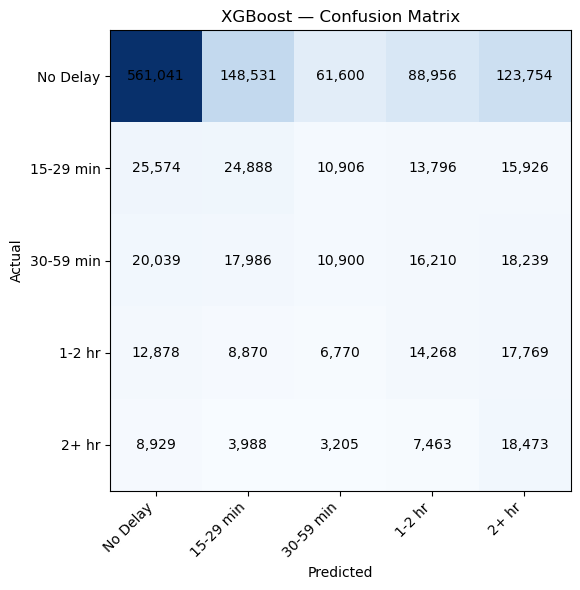

In [12]:
results.append(evaluate('XGBoost', xgb_model, X_test_xgb, y_test))

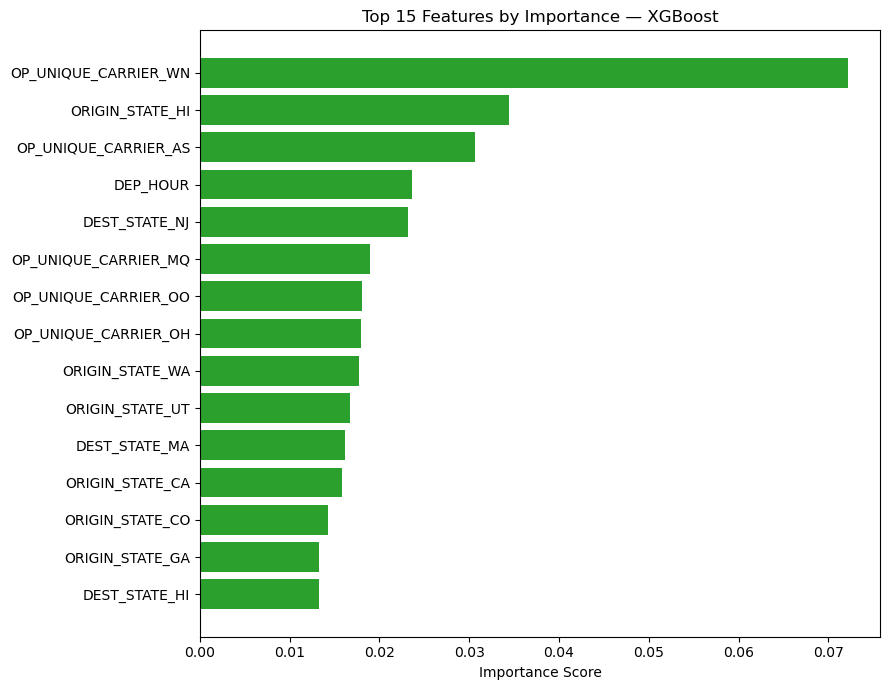

In [13]:
# TODO (Aryan): Feature importance plot — For numerical features only
# 1. Get importances from xgb_model.feature_importances_
# 2. Map to numerical feature names
# 3. Find the top 15
# 4. Plot as horizontal bar chart

importances = xgb_model.feature_importances_
numerical_features = X_train.select_dtypes(include=[np.number]).columns

importance_df = pd.DataFrame({
    'feature': numerical_features,
    'importance': importances,
})

top15 = importance_df.nlargest(15, 'importance').sort_values('importance')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15['feature'], top15['importance'], color='#2ca02c')

ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Features by Importance — XGBoost')
plt.tight_layout()
plt.show()

---
# Dennis — RNN

Needs `pip install tensorflow`.

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# TODO (Dennis): Preprocessing
# 1. Scale X_train and X_test with StandardScaler
# 2. Reshape to 3D: (samples, 1, features) — RNN expects 3D input


In [ ]:
# TODO (Dennis): Build and train
# 1. Build Sequential: SimpleRNN(64) -> Dropout(0.3) -> Dense(32) -> Dense(5, softmax)
# 2. Compile with optimizer='adam', loss='sparse_categorical_crossentropy'
# 3. Fit with epochs=10, batch_size=1024, validation_split=0.1


In [ ]:
# TODO (Dennis): Evaluate
# 1. Get probabilities: y_prob = rnn_model.predict(X_test_rnn)  # shape (N, 5)
# 2. Get predictions: y_pred = y_prob.argmax(axis=1)
# 3. Print weighted metrics (accuracy, precision, recall, F1, AUC-ROC with multi_class='ovr')
# 4. Plot confusion matrix (5x5)
# 5. Append results dict to results list


---
# Compare all models

In [ ]:
comparison = pd.DataFrame(results).set_index('Model')
comparison.round(4)

In [ ]:
comparison.plot.bar(figsize=(10, 5), title='Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()